## BBM 409 - Programming Assignment 1

* You can add as many cells as you want in-between each question.
* Please add comments to your code to explain your work.  
* Please add Markdown cells to answer the (non-coding) questions in the homework text. You can, however, refer to the outputs of code cells without adding them as images to the Markdown cell unless you are requested to do otherwise.
* Please be careful about the order of runs of cells. Doing the homework, it is likely that you will be running the cells in different orders, however, they will be evaluated in the order they appear. Hence, please try running the cells in this order before submission to make sure they work.    
* Please refer to the homework text for any implementation detail. Though you are somewhat expected to abide by the comments in the below cells, they are mainly just provided for guidance. That is, as long as you are not completely off this structure and your work pattern is understandable and traceable, it is fine. For instance, you do not have to implement a particular function within a cell just because the comment directs you to do so.
* This document is also your report. Show your work.

###  Kadir Çağrı Kuzaytepe - 2210356036

## Understanding Perceptron Learning Algorithm (100 points +5 points)

### 1. Data Loading and Exploration (5 points)
* Brief overview of the task.
* Description of the dataset used for analysis.

In [12]:
## Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
banknote_authentication = fetch_ucirepo(id=267) 
  
# data (as pandas dataframes) 
# Features and target variables
X = banknote_authentication.data.features 
y = banknote_authentication.data.targets 
  
# metadata 
print(banknote_authentication.metadata) 
  
# variable information 
print(banknote_authentication.variables) 

{'uci_id': 267, 'name': 'Banknote Authentication', 'repository_url': 'https://archive.ics.uci.edu/dataset/267/banknote+authentication', 'data_url': 'https://archive.ics.uci.edu/static/public/267/data.csv', 'abstract': 'Data were extracted from images that were taken for the evaluation of an authentication procedure for banknotes.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1372, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C55P57', 'creators': ['Volker Lohweg'], 'intro_paper': None, 'additional_info': {'summary': 'Data were extracted from images that were taken from genuine and forged banknote-like specimens.  For digitization, an industrial camera usually used for print inspection was used. The final im

In [14]:
## Read the regression data and transform it into a Numpy array collection.
## (See pandas and numpy functions)
data = pd.concat([X])
lfd_data = pd.concat([X,y],axis = 1)
print(data.shape)
# import scipy.stats as stats
# shapiro_test = stats.shapiro(data)
# print("Shapiro-Wilk Test Statistic:", shapiro_test.statistic)
# print("p-value:", shapiro_test.pvalue)


(1372, 4)


In [15]:

# Checking the size of the dataset
print(f"Dataset Size: {data.shape}") 

# Print the first 5 rows
print("\nFirst few rows of the dataset:")
print(data.head())

# Print the features and target variable names
print("\nFeature names:", data.columns[:-1].tolist())
print("Target variable name:", data.columns[-1])

# Summary statistics
print("\nSummary statistics:")
print(data.describe())

# Check for missing values
missing_values = data.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)
if missing_values.any():
    data_cleaned = data.dropna()
    print("\nDropped rows with missing values. New size:", data_cleaned.shape)
else:
    data_cleaned = data

# Final cleaned data overview
print("\nOverview of the cleaned dataset:")
print(data_cleaned.head() if 'data_cleaned' in locals() else data.head())


Dataset Size: (1372, 4)

First few rows of the dataset:
   variance  skewness  curtosis  entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880

Feature names: ['variance', 'skewness', 'curtosis']
Target variable name: entropy

Summary statistics:
          variance     skewness     curtosis      entropy
count  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657
std       2.842763     5.869047     4.310030     2.101013
min      -7.042100   -13.773100    -5.286100    -8.548200
25%      -1.773000    -1.708200    -1.574975    -2.413450
50%       0.496180     2.319650     0.616630    -0.586650
75%       2.821475     6.814625     3.179250     0.394810
max       6.824800    12.951600    17.927400     2.449500

Missing values in each column:
variance    0
skewness    0
curtosis    

In [16]:
# Convert the DataFrame to a Numpy array
data_array = data_cleaned.to_numpy()

print("\nShape of the NumPy array:", data_array.shape)

print("\nFirst few rows of the NumPy array:")
print(data_array[:5]) 



Shape of the NumPy array: (1372, 4)

First few rows of the NumPy array:
[[ 3.6216   8.6661  -2.8073  -0.44699]
 [ 4.5459   8.1674  -2.4586  -1.4621 ]
 [ 3.866   -2.6383   1.9242   0.10645]
 [ 3.4566   9.5228  -4.0112  -3.5944 ]
 [ 0.32924 -4.4552   4.5718  -0.9888 ]]


### 2. Data Preprocessing (5 points)
Explain the preprocessing steps taken and their rationale.

#### Feature Scaling Techniques:
Feature scaling is important for many machine learning algorithms, especially those based on distance metrics (e.g., k-nearest neighbors, support vector machines) and gradient descent optimization (e.g., linear regression, logistic regression).

Some common feature scaling techniques include:

1. **Standardization (Z-score normalization):** It scales the features to have a mean of 0 and a standard deviation of 1.
2. **Min-Max Scaling:** It scales the features to a fixed range, typically between 0 and 1.
3. **Robust Scaling:** It scales the features based on percentiles, making it robust to outliers.

You can use these scaled features for training your machine learning models.

Remember, the choice of feature selection and feature scaling techniques can significantly impact the performance of your models. It's essential to experiment and choose the techniques that work best for your specific dataset and machine learning tasks.

In [38]:
## Analyze the dataset and decide whether scaling is needed. 
## Explain your choices in a brief comment. 

##Standardization is chosen here because it centers the data around zero with unit variance, which is suitable given that the dataset may have some outliers but doesn’t contain extreme values that would skew the data significantly. 
##This choice should enhance model training for algorithms sensitive to feature scale, ensuring features contribute equally to the model’s learning process.

#### Training and Validation Split
1. Explain why it’s important to use the validation set to evaluate your model instead
of relying solely on the training data.
Comment: Using a validation set is important because it helps us see how well the model will perform on new data. If we only evaluate on the training data, the model may seem accurate just because it memorized the training examples. Testing on a separate validation set shows if the model can generalize to unseen data, which is crucial to avoid overfitting and helps us fine-tune the model for better real-world performance.
3. Discuss how evaluating the model on unseen
data helps in assessing its generalization capability.
Comment: Evaluating the model on unseen data is essential to assess its generalization capability because it shows how well the model can apply what it learned to new, unfamiliar examples. If a model performs well on unseen data, it indicates that it has not just memorized the training data but has learned patterns that can apply more broadly. 

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to float64
X_train = np.asarray(X_train, dtype='float64')
y_train = np.asarray(y_train, dtype='float64')

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (1097, 4)
Shape of X_test: (275, 4)
Shape of y_train: (1097, 1)
Shape of y_test: (275, 1)


### 3. Implementing Perceptron for Binary Classification (20 points)

Explain the reason behind the application of perceptron learning algorithm on this type of data.

Comment: 
For this type of data, the Perceptron is suitable because it iteratively adjusts its weights to minimize classification errors, eventually learning a boundary that can accurately classify the data if it is linearly separable.

In [18]:
y_train = np.asarray(y_train, dtype='float64')

# Initialize parameters
bias = 0
threshold = 0.5
learning_rate = 0.001 
w = np.zeros(X_train.shape[1]) 

def step(weighted_sum):
    return 1 if weighted_sum > threshold else 0


def perceptron(X, y_train, epochs):
    num_features = X.shape[1] 
    global w, bias  
    w = np.zeros(num_features)
    
    for epoch in range(epochs):
        for x, y in zip(X, y_train):
            # Calculate the weighted sum
            weighted_sum = np.dot(w, x) + bias

            # Make a prediction
            y_predict = step(weighted_sum)

            # Update the weights and bias
            delta_w = learning_rate * (y - y_predict).item() * x 
            delta_b = learning_rate * (y - y_predict).item()

            w += delta_w
            bias += delta_b

Discuss how the choice of learning rate and the number of epochs might affect the
training process. What happens with a very small or very large learning rate?

When I decreased the number of epochs, the model’s accuracy dropped, likely because it didn’t have enough time to fully learn the data patterns. Increasing the learning rate also negatively affected accuracy, resulting in only 79%, as the model made larger updates that caused it to overshoot optimal values. This highlights the importance of selecting an appropriate learning rate and a sufficient number of epochs to balance between learning efficiently and reaching high accuracy.

In [19]:
# Accuracy implementation

#### Train the Perceptron

In [20]:
## Train the Perceptron model on the training set.

epochs = 1000
perceptron(X_train, y_train, epochs)

# Output the learned weights and bias
print("Learned weights:", w)
print("Learned bias:", bias)


Learned weights: [-0.07627482 -0.08050051 -0.07635562 -0.00441908]
Learned bias: 0.46200000000000035


#### Prediction on Training Data

In [21]:
# Predicting on the training data

def predict(X):
    predictions = []
    for x in X:
        weighted_sum = np.dot(w, x) + bias
        y_predict = step(weighted_sum)
        predictions.append(y_predict)
    return np.array(predictions)

# Predicting on the training data
y_train_predict = predict(X_train)
y_train_flattened = y_train.flatten()
accuracy_train = np.mean(y_train_predict == y_train_flattened) * 100 

print("Training Accuracy:", accuracy_train)

Training Accuracy: 99.08842297174111


### 4. Evaluating Perceptron for Binary Classification (25 points)

#### Prediction on Validation Data

In [22]:
## Evaluate the model's performance on the test set by calculating accuracy.
# Predicting on the test data
y_test_predict = predict(X_test)

y_test_flattened = y_test.to_numpy().flatten()

accuracy_test = np.mean(y_test_predict == y_test_flattened) * 100 
print("Testing Accuracy:", accuracy_test)


Testing Accuracy: 98.54545454545455


Answer the Guiding Questions:
1. What does accuracy tell us about the performance of the model?
2. Why is accuracy sometimes not enough, especially in cases where the data is imbal-
anced? Explain a scenario where a high accuracy might be misleading.

Comment 1: 
Accuracy indicates the percentage of correctly predicted instances out of the total predictions, giving us a general sense of how well the model is performing.
Comment 2:
Accuracy isn’t always reliable with imbalanced data because it doesn’t consider if one class has way more examples than the other. For example, in a dataset where only 1% of cases are positive , a model that always predicts “negative” could still get 99% accuracy. This would look like high accuracy but wouldn’t be useful since it misses all the positive cases, showing that accuracy alone can give a false sense of success.

In [23]:

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score


def calculate_metrics(y_true, y_pred):

    accuracy = accuracy_score(y_true,y_pred)
    precision = precision_score(y_true,y_pred)
    recall = recall_score(y_true,y_pred)
    f1 = f1_score(y_true,y_pred)

    return accuracy, precision, recall, f1

y_pred_train =  predict(X_train)
# Calculate and print metrics
accuracy_train, precision_train, recall_train, f1_train = calculate_metrics(y_train.flatten(), y_pred_train)

print(f"Training Accuracy: {accuracy_train}")
print(f"Training Precision: {precision_train}")
print(f"Training Recall: {recall_train}")
print(f"Training F1 Score: {f1_train}")

Training Accuracy: 0.9908842297174111
Training Precision: 0.9937369519832986
Training Recall: 0.9855072463768116
Training F1 Score: 0.9896049896049897


Answer the Guiding Questions:
1. In what types of problems is precision more important than recall? Give an example
scenario where high precision is desirable but low recall might be acceptable.
2. In what cases is recall more critical? Discuss an example where missing true positives
is more harmful than having false positives.
3. When is the F1 score a better measure than accuracy? Explain why balancing
precision and recall is important in some contexts.
4. What are the limitations of using F1 score alone?

Answer 1:
Precision is more important than recall in cases where it’s crucial to minimize false positives, meaning we only want to classify something as positive if we’re very confident it actually is. One example is in email spam filtering: we want high precision to avoid marking important or non-spam emails as spam (false positives). It’s acceptable if the filter doesn’t catch every spam email (low recall), as users would rather see a few spam messages in their inbox than miss important emails due to incorrect filtering.

Answer 2:
Recall is really important when missing true positives can have serious consequences. For example, in disease screening, like for cancer, it’s more harmful to miss a case where someone actually has the disease (a false negative) than to accidentally flag someone who doesn’t (a false positive). If someone has cancer and the test misses it, they won’t get the treatment they need in time, which could be dangerous. It’s better to have some false positives and do more testing than to miss people who really need help.

Answer 3:
The F1 score is better than accuracy when the data is imbalanced or when we care about both false positives and false negatives. Accuracy just tells us the overall correct predictions, but the F1 score combines precision and recall, so it shows how well the model is doing with both types of mistakes. Balancing precision and recall is important in situations where we need to catch as many positives as possible (high recall) but also avoid too many wrong positives (high precision). For example, in fraud detection, we want to catch fraud cases (recall) but not flag too many real transactions by mistake (precision), so the F1 score helps us find a good balance.

Answer 4:

The F1 score has some limits because it only balances precision and recall, so it doesn’t show us how many true positives, false positives, or false negatives there actually are. This can be a problem if our classes are imbalanced because it doesn’t tell us how often each class shows up or the overall accuracy. Also, if we need to focus more on either precision or recall, the F1 score isn’t enough by itself. It’s usually best to look at F1 along with other metrics like accuracy, precision, or recall to get a full understanding of how the model is really doing.


### 5. Visualization of the Hyperplane (40 + 5 points)

In this section, you will explore how the Perceptron Learning Algorithm forms the de-
cision boundary (or hyperplane) that separates the two classes. To be able to do that
you will reduce the feature space to two dimensions, train the Perceptron on the selected
features, and visualize the hyperplane. The goal is to understand how the Perceptron
changes the decision boundary as the data changes, and how it adapts based on the
features used.

#### Step 1: Feature Selection Using Correlation Analysis (10 points)

1. Correlation Analysis: One effective way to reduce the number of features is by
analyzing the correlation between them. Highly correlated features may provide re-
dundant information, so you can select two less correlated features for visualization.
2. Compute the correlation matrix: Analyze the relationship between the four features
(variance, skewness, kurtosis, and entropy) to identify pairs of features with low
correlation.

          variance  skewness  curtosis   entropy
variance  1.000000  0.264026 -0.380850  0.276817
skewness  0.264026  1.000000 -0.786895 -0.526321
curtosis -0.380850 -0.786895  1.000000  0.318841
entropy   0.276817 -0.526321  0.318841  1.000000


<Axes: >

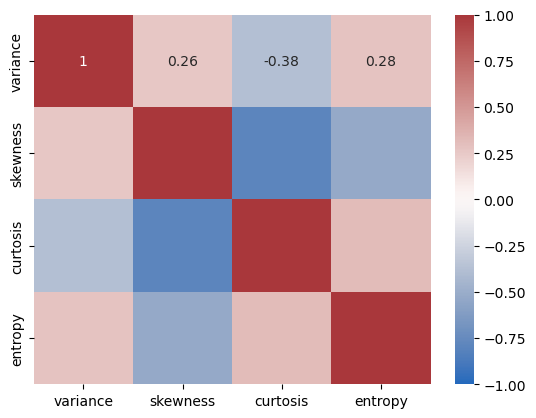

In [24]:
# Compute the correlation matrix
import seaborn as sns
correlation_matrix = data_cleaned.corr()
print(correlation_matrix)
# Display the correlation matrix as a heatmap
sns.heatmap(correlation_matrix.round(2), annot=True, vmin=-1, vmax=1, center=0,cmap='vlag')


3. Choose two features: Based on the correlation analysis, select two features that are
least correlated (e.g., variance and skewness) to visualize the Perceptron’s decision
boundary.

In [25]:

features_to_select = ['variance', 'skewness']  

# Separate features and target variable
X = data[features_to_select]
#X = data.drop(columns_to_drop, axis=1)

y = banknote_authentication.data.targets


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()  
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to float64
X_train = np.asarray(X_train, dtype='float64')
y_train = np.asarray(y_train, dtype='float64')

# Split the selected features into training and validation sets if not done yet

#### Step 2: Train the Perceptron on Selected Features (10 points)

1. Retrain the Perceptron: After selecting two features, train the Perceptron using
only these two features. Use the same training and evaluation process as before,
but now the model will work in a two-dimensional feature space.

In [26]:
## Train the Perceptron model on the training set.

perceptron(X_train,y_train,1000)

# Predicting on the training data
y_train_predict = predict(X_train)
y_train_flattened = y_train.flatten()
accuracy_train = np.mean(y_train_predict == y_train_flattened) * 100  # Percentage

print("Training Accuracy:", accuracy_train)
# Predicting on the training data
print("Training Accuracy:", accuracy_train)

Training Accuracy: 80.85688240656336
Training Accuracy: 80.85688240656336


2. Visualize the decision boundary (hyperplane): Once the Perceptron is trained, plot
the decision boundary (hyperplane) to see how the Perceptron separates the two
classes in 2D.

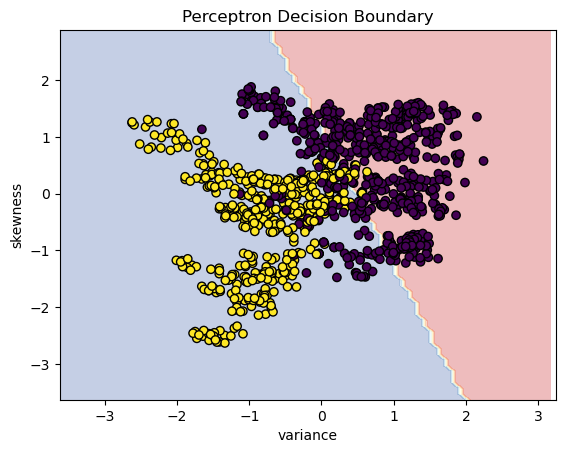

In [27]:
# Function to plot the decision boundary
import matplotlib.pyplot as plt
def plot_decision_boundary(X, y, model):
    # Create a mesh grid for plotting decision boundary
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Predict for each point in the mesh grid
    Z = np.array([step(np.dot(w, np.array([i, j])) + bias) for i, j in zip(np.ravel(xx), np.ravel(yy))])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    
    # Scatter plot of training data
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', marker='o')
    plt.title('Perceptron Decision Boundary')
    plt.xlabel('variance')
    plt.ylabel('skewness')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()
plot_decision_boundary(X_train,y_train,1000)
# Plot the decision boundary using the selected features and trained model

#### Step 3: Experiment with Different Features (10 points)

After visualizing the decision boundary for one pair of features, try selecting different
combinations of features (e.g., variance and entropy) and retrain the Perceptron. Compare
how the hyperplane changes with different features. This helps in understanding how the
Perceptron’s decision-making process adapts to different feature sets.

Answer the guiding
questions:
1. How does the decision boundary change when you use different pairs of features?
2. Can you find a pair of features that leads to better separation between the two
classes?

Answer 1 : 
When I experimented with different pairs of features, I noticed that the decision boundary became less clear and more ambiguous. T
his change in features led to a lower accuracy, as the model struggled to create a distinct separation between the two classes.

Answer 2:
I couldn't find a pair of features that resulted in better separation between the two classes. 
The alternative feature pairs I tried did not improve the model’s ability to distinguish between classes, 
and the decision boundary was less distinct, leading to lower accuracy compared to the initial feature pair.

#### Bonus Step 4: Incrementally Add Data (+ 5 points)

1. Visualizing Incremental Learning: Another experiment to help understand the behavior of the Perceptron is to add data incrementally. Start with a small portion of
the dataset and progressively add more data points to train the Perceptron.

2. Observe how the decision boundary shifts: As you add more data, observe how the
hyperplane shifts and adapts to new points. This will help you understand how the
Perceptron continuously adjusts the boundary to separate the classes.

#### Step 5: Analyzing the Hyperplane (5 points)

After running the experiments, analyze the hyperplane’s behavior across different feature
sets and data inputs. Reflect on how the Perceptron algorithm adapts to the data and how
different feature combinations lead to different decision boundaries. Anwer the guiding
questions:
1. Why does the hyperplane change with different features or data points?
2. How does the decision boundary relate to the linearly separable nature of the data?

Answer 1:

The hyperplane changes with different features or data points because the Perceptron algorithm adjusts based on the feature values and their influence on class separation. Different feature combinations provide different patterns and distributions in the data, so the algorithm shifts the hyperplane to best separate the classes according to these new patterns. When the feature values vary significantly, the decision boundary adjusts to fit the distribution and relationship of the selected features to the classes.

Answer 2:

The decision boundary created by the Perceptron is only effective if the data is linearly separable, meaning it can be divided by a straight line (or plane in higher dimensions). If the data is linearly separable, the Perceptron will successfully find a hyperplane that fully separates the classes. However, if the data isn’t linearly separable, the Perceptron will struggle, leading to a boundary that doesn’t completely separate the classes, resulting in lower accuracy or ambiguous boundaries.

#### Step 6: Fisher’s Linear Discriminant Projection (10 points)

In this step, you will implement Fisher’s Linear Discriminant (LD) to project the
dataset onto a 1D space and visualize the distribution of the two classes in the projected
space using a histogram. The goal of Fisher’s LD is to find the direction in the feature
space that maximizes the separation between two classes while minimizing the variance
within each class. This technique projects the data onto a single dimension where the
separation between the classes is optimized.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Seçilen özellikleri belirleme ve veriyi ayırma
selected_features = ['variance', 'skewness']  # Özellik adlarını ihtiyaçlarınıza göre ayarlayın
X_selected = lfd_data.iloc[:, :-1].astype(float).values
print(X_selected.shape)

# Özellikleri normalize etme
X_normalized = (X_selected - X_selected.mean(axis=0)) / X_selected.std(axis=0)


# Fisher LD Projeksiyon Fonksiyonları
# 1. Fisher LD Projeksiyon Vektörünü Hesaplama
def fisher_ld_projection(class1, class2):
    mean1 = np.mean(class1, axis=0)
    mean2 = np.mean(class2, axis=0)
    S1 = np.cov(class1, rowvar=False)
    S2 = np.cov(class2, rowvar=False)
    Sw = S1 + S2  # Sınıf içi saçılım matrisi
    w = np.linalg.inv(Sw).dot(mean2 - mean1)  # Fisher'ın LD yön vektörü
    return w

# 2. Fisher LD Yönüne Veriyi Proje Etme
def project_data(data, w):
    return data.dot(w)


(1372, 4)


In [32]:
# Sınıf ayırma işlemi
features = lfd_data.iloc[:, :-1]  # All rows, all columns except the last one
targets = lfd_data.iloc[:, -1]     # All rows, only the last column

print(features)

class1 = features[targets == 0].values
class2 = features[targets == 1].values
print(class1)
# Fisher LD yön vektörünü hesaplama
w = fisher_ld_projection(class1, class2),
w = np.array(w).reshape(-1, 1)
print(w.shape)

# Veriyi Fisher LD yönüne projekte etme
projected_data = project_data(X_normalized, w)

# Projeksiyon verisini kontrol etme
print("Projected Data:", projected_data)

      variance  skewness  curtosis  entropy
0      3.62160   8.66610   -2.8073 -0.44699
1      4.54590   8.16740   -2.4586 -1.46210
2      3.86600  -2.63830    1.9242  0.10645
3      3.45660   9.52280   -4.0112 -3.59440
4      0.32924  -4.45520    4.5718 -0.98880
...        ...       ...       ...      ...
1367   0.40614   1.34920   -1.4501 -0.55949
1368  -1.38870  -4.87730    6.4774  0.34179
1369  -3.75030 -13.45860   17.5932 -2.77710
1370  -3.56370  -8.38270   12.3930 -1.28230
1371  -2.54190  -0.65804    2.6842  1.19520

[1372 rows x 4 columns]
[[ 3.6216   8.6661  -2.8073  -0.44699]
 [ 4.5459   8.1674  -2.4586  -1.4621 ]
 [ 3.866   -2.6383   1.9242   0.10645]
 ...
 [ 0.01727  8.693    1.3989  -3.9668 ]
 [ 3.2414   0.40971  1.4015   1.1952 ]
 [ 2.2504   3.5757   0.35273  0.2836 ]]
(4, 1)
Projected Data: [[-2.37556868]
 [-3.10582861]
 [-1.92481504]
 ...
 [ 0.58394647]
 [ 1.25671527]
 [ 2.36150024]]


While not mandatory, it can be highly instructive to visualize the projection direction computed by Fisher’s LD in the original 2D feature space. This will help you understand how the data is being projected onto a 1D space and why this direction is optimal for class separation.

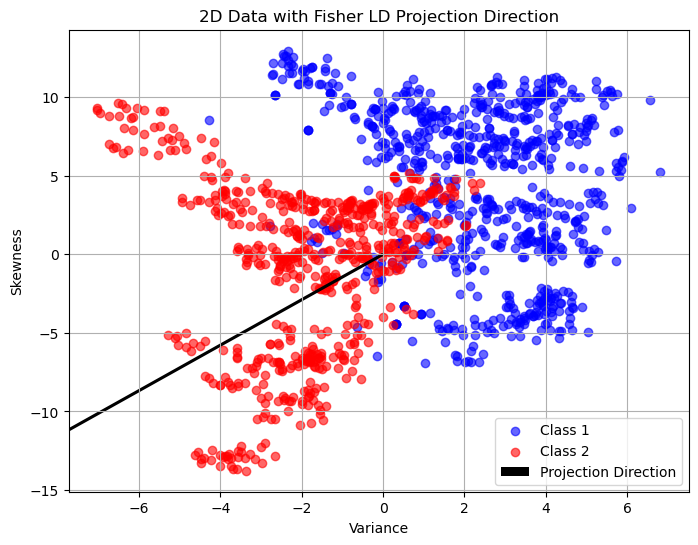

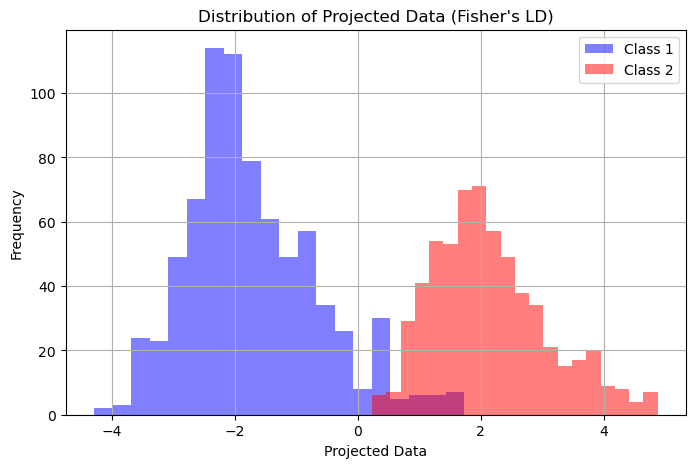

In [33]:
data_mean = X_normalized.mean(axis=0)

# 2. 2D Veriyi Fisher LD Projeksiyon Yönü ile Çizme
plt.figure(figsize=(8, 6))

# İki sınıfın verilerini scatter plot ile çizme
plt.scatter(class1[:, 0], class1[:, 1], alpha=0.6, label="Class 1", color="blue")
plt.scatter(class2[:, 0], class2[:, 1], alpha=0.6, label="Class 2", color="red")
# Fisher LD yön vektörünü görselleştirme
scale = 4  # Vektörün uzunluğunu ayarlamak için
plt.quiver(data_mean[0],data_mean[1], w[0], w[1], scale=scale, color="black", width=0.005, label="Projection Direction")

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("2D Data with Fisher LD Projection Direction")
plt.legend()
plt.grid(True)
plt.show()

# 3. Projeksiyon Verisinin Histogramını Çizme
plt.figure(figsize=(8, 5))
plt.hist(projected_data[targets == 0], alpha=0.5, label="Class 1", bins=20, color="blue")
plt.hist(projected_data[targets == 1], alpha=0.5, label="Class 2", bins=20, color="red")
plt.xlabel("Projected Data")
plt.ylabel("Frequency")
plt.title("Distribution of Projected Data (Fisher's LD)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot the histogram of the projected data

Answer the guiding questions:
1. How well does Fisher’s LD separate the two classes in the 1D projected space?
2. Compare the separation of the two classes in the original 2D space (used in the
Perceptron) versus the 1D Fisher’s LD projection. What do you observe about the
class distributions in these spaces?

Answer 1:

Fisher’s Linear Discriminant (LD) generally does a good job of separating the two classes in the 1D projected space, 
as it is designed to maximize class separation while minimizing within-class variance. 
In the projected 1D space, the two classes often appear more distinct, with less overlap compared to their original distribution, 
making it easier to differentiate between them.

Answer 2:
In the original 2D space with the Perceptron, the separation between classes depends on the specific features and how the decision boundary is placed. 
But in the 1D space created by Fisher’s LD, the classes are projected in a way that maximizes their separation. 
This makes the classes look more distinct on the 1D line, with less overlap, compared to the 2D space. 
Fisher’s LD reduces the variance within each class and increases the distance between them, so it’s often easier to tell the classes apart in this 1D projection.